# cell 1

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy import stats

from model import simulate_monod, residuals_monod

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

# Load data
df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
t_data = df['time_h'].values
X_data = df['biomass_gL'].values
S_data = df['substrate_gL'].values
X0, S0 = X_data[0], S_data[0]
n_points = len(t_data)

print(f"Loaded {n_points} data points")

Loaded 31 data points


# cell 2


In [3]:
def fit_monod_once_bootstrap(t_boot, X_boot, S_boot, X0, S0, p0=None):
    """
    Fit Monod to a bootstrap resample, handling duplicate time values.

    Strategy: solve_ivp on unique sorted time grid, then index back to
    the (potentially repeated) resampled data for residual computation.
    """
    if p0 is None:
        p0 = [0.4, 0.1, 0.5]

    # Sort the bootstrap sample by time (stable)
    sort_idx = np.argsort(t_boot)
    t_sorted = t_boot[sort_idx]
    X_sorted = X_boot[sort_idx]
    S_sorted = S_boot[sort_idx]

    # Get unique time grid for solve_ivp
    t_unique, inverse_idx = np.unique(t_sorted, return_inverse=True)

    if len(t_unique) < 4:
        return None  # need at least 4 unique time points for a meaningful fit

    def residuals_boot(params):
        X_pred_u, S_pred_u = simulate_monod(params, t_unique, X0, S0)
        # Check for NaN (solve_ivp failure)
        if np.any(np.isnan(X_pred_u)) or np.any(np.isnan(S_pred_u)):
            # Return large residuals so optimizer moves away
            return np.full(2 * len(t_sorted), 1e3)

        # Map unique-grid predictions back to the resampled data
        X_pred = X_pred_u[inverse_idx]
        S_pred = S_pred_u[inverse_idx]

        X_scale = max(np.nanmax(X_sorted), 1e-6)
        S_scale = max(np.nanmax(S_sorted), 1e-6)

        X_res = (X_pred - X_sorted) / X_scale
        S_res = (S_pred - S_sorted) / S_scale

        return np.concatenate([X_res, S_res])

    try:
        result = least_squares(
            residuals_boot, x0=p0,
            bounds=([0.01, 0.001, 0.1], [2.0, 10.0, 1.0]),
            method='trf', verbose=0,
        )
        if result.success:
            return result.x
    except Exception as e:
        pass
    return None


# Bootstrap loop
N_BOOTSTRAP = 500
np.random.seed(42)

bootstrap_params = []
n_fails = 0

for i in range(N_BOOTSTRAP):
    idx = np.random.choice(n_points, size=n_points, replace=True)
    t_boot = t_data[idx]
    X_boot = X_data[idx]
    S_boot = S_data[idx]

    # Use original ground-truth initial conditions (not resampled, for stability)
    params = fit_monod_once_bootstrap(t_boot, X_boot, S_boot, X0=X0, S0=S0)

    if params is not None:
        bootstrap_params.append(params)
    else:
        n_fails += 1

    if (i + 1) % 100 == 0:
        print(f"  Completed {i+1}/{N_BOOTSTRAP} ({n_fails} failures so far)")

bootstrap_params = np.array(bootstrap_params)
print(f"\nFinal: {len(bootstrap_params)} successful fits, {n_fails} failures")
print(f"Shape: {bootstrap_params.shape}")

  Completed 100/500 (0 failures so far)
  Completed 200/500 (0 failures so far)
  Completed 300/500 (0 failures so far)
  Completed 400/500 (0 failures so far)
  Completed 500/500 (0 failures so far)

Final: 500 successful fits, 0 failures
Shape: (500, 3)


# cell 3


In [4]:
# 95% CI via percentiles of the bootstrap distribution
param_names = ['mu_max', 'Ks', 'Yxs']
ground_truth = [0.45, 0.12, 0.50]

print(f"{'Param':<10} {'Median':>10} {'2.5%':>10} {'97.5%':>10} {'Truth':>10} {'CI width':>12}")
print("-" * 65)
for i, name in enumerate(param_names):
    values = bootstrap_params[:, i]
    median = np.median(values)
    lo, hi = np.percentile(values, [2.5, 97.5])
    truth = ground_truth[i]
    width = hi - lo
    print(f"{name:<10} {median:>10.4f} {lo:>10.4f} {hi:>10.4f} {truth:>10.4f} {width:>12.4f}")

Param          Median       2.5%      97.5%      Truth     CI width
-----------------------------------------------------------------
mu_max         0.5036     0.4607     1.0866     0.4500       0.6259
Ks             1.0947     0.3821     6.4257     0.1200       6.0435
Yxs            0.4443     0.4352     0.4536     0.5000       0.0184


# cell 4


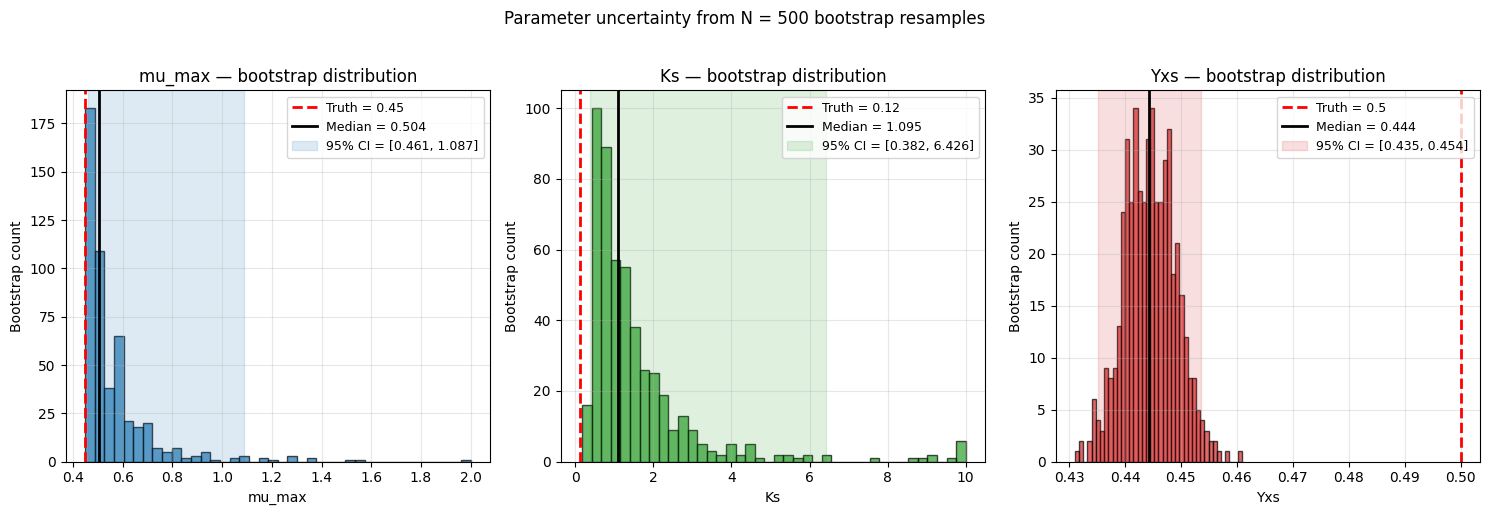

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['C0', 'C2', 'C3']
xlims_truths = [(0.30, 0.65), (0.001, None), (0.30, 0.60)]  # tighter views for clarity

for i, (name, color, truth) in enumerate(zip(param_names, colors, ground_truth)):
    values = bootstrap_params[:, i]
    median = np.median(values)
    lo, hi = np.percentile(values, [2.5, 97.5])

    axes[i].hist(values, bins=40, color=color, alpha=0.7, edgecolor='black')
    axes[i].axvline(truth, color='red', linestyle='--', linewidth=2, label=f'Truth = {truth}')
    axes[i].axvline(median, color='black', linestyle='-', linewidth=2, label=f'Median = {median:.3f}')
    axes[i].axvspan(lo, hi, alpha=0.15, color=color, label=f'95% CI = [{lo:.3f}, {hi:.3f}]')

    axes[i].set_xlabel(name)
    axes[i].set_ylabel('Bootstrap count')
    axes[i].set_title(f'{name} — bootstrap distribution')
    axes[i].legend(loc='best', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle(f'Parameter uncertainty from N = {len(bootstrap_params)} bootstrap resamples', y=1.02)
plt.tight_layout()
plt.savefig('../figures/08_bootstrap_distributions.png', bbox_inches='tight')
plt.show()

# cell 5

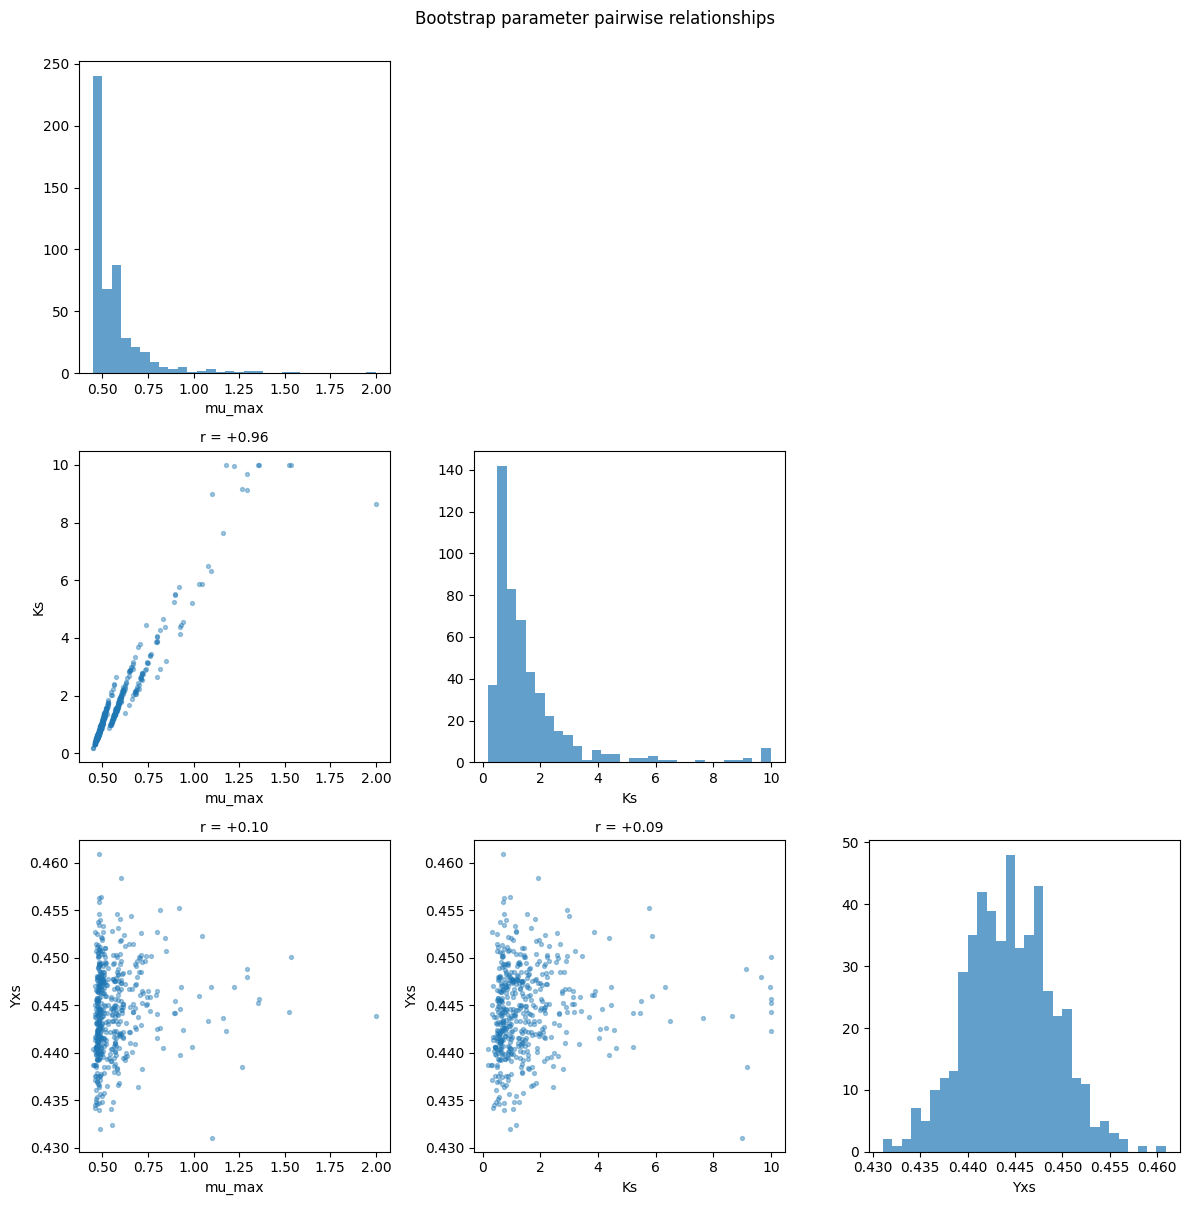

In [6]:
# Scatter matrix of bootstrap parameters
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if i == j:
            ax.hist(bootstrap_params[:, i], bins=30, color='C0', alpha=0.7)
            ax.set_xlabel(param_names[i])
        elif i > j:
            ax.scatter(bootstrap_params[:, j], bootstrap_params[:, i],
                       s=8, alpha=0.4, color='C0')
            ax.set_xlabel(param_names[j])
            ax.set_ylabel(param_names[i])
            # Add correlation coefficient
            r = np.corrcoef(bootstrap_params[:, i], bootstrap_params[:, j])[0, 1]
            ax.set_title(f'r = {r:+.2f}', fontsize=10)
        else:
            ax.axis('off')

plt.suptitle('Bootstrap parameter pairwise relationships', y=1.00)
plt.tight_layout()
plt.savefig('../figures/09_parameter_correlations.png', bbox_inches='tight')
plt.show()

**Observation:** Ks and μ_max show a striking +0.96 correlation across
bootstrap resamples, indicating these two parameters are essentially
non-identifiable from this dataset — the optimizer can trade one off
against the other along an extended ridge in parameter space and obtain
nearly the same fit quality. Yxs, by contrast, is well-decoupled from
both kinetic parameters (|r| < 0.1) because it is determined primarily
by the asymptotic biomass-to-substrate ratio, which is independent of
the kinetic shape.

This is the mechanistic explanation for the poor Ks recovery observed
earlier: it is not that Ks information is missing, but that the
data cannot distinguish (Ks, μ_max) pairs that lie along the correlation
ridge. Breaking this coupling requires data at substrate concentrations
comparable to Ks itself — i.e., chemostat experiments at low dilution
rates.